In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

# from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv', index_col=0)
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
# drop all rows where run column is 5
r_table = r_table[r_table['run'] != 5]
r_table.run.unique()

array([0, 1, 2, 3, 4])

## Real

In [3]:
def impute_with_median(data):
    median_rt = np.nanmedian(data)
    rt_imputed = data.copy()
    rt_imputed[rt_imputed == 0] = median_rt
    return rt_imputed

def impute_with_lin_interpolation(data):
    oshape = data.shape
    rt_imputed = data.flatten().copy()
    idx = np.arange(rt_imputed.size)
    good = rt_imputed != 0
    
    # interpolate where values are zero
    rt_imputed[rt_imputed == 0] = np.interp(
        idx[~good], 
        idx[good], 
        rt_imputed[good], 
    )
    return rt_imputed.reshape(oshape)

### Calculating RT and evidence for 5 different choices

In [4]:
r_table[["subj", "target", "t_calib", "resp"]].head()

,subj,target,t_calib,resp
0,1,159.0,145.788047,148.685925
1,1,123.0,136.060195,129.253756
2,1,51.0,33.954344,124.965094
3,1,159.0,145.788047,145.702460
4,1,15.0,18.896223,144.334808


   subj      att   coh      exp_al        rt  choice
0     1  divided  high    expected  1.025000       4
1     1  focused  high  unexpected  0.250000       3
2     1  divided  high    expected  0.725000       4
3     1  divided   low  unexpected  0.166667       4
4     1  divided   low    expected  0.658333       4


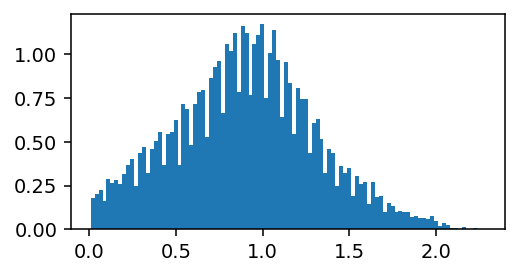

In [5]:
data = r_table[['subj', "att", "coh", "exp_al", "target", "resp"]].copy()

raw_rt = (r_table['f_resp'].values - 250) * (1/120)
# aug_rt = impute_with_lin_interpolation(raw_rt)

col_to_angle = {0: 15, 1: 51, 2: 87, 3: 123, 4: 159}
def map_response(subj, resp):
    # select row for subject (1-indexed)
    row = med[subj - 1]
    # find index of closest representative angle
    idx = np.abs(row - resp).argmin()
    return col_to_angle[idx]
data['afc_resp'] = data.apply(lambda r: map_response(r['subj'], r['resp']), axis=1)

resp = data['afc_resp'].map(median_key)

data['rt'] = raw_rt
data['choice'] = resp

# drop where rt == 0
data = data[data['rt'] != 0].reset_index(drop=True)

print(data[['subj', "att", "coh", "exp_al", "rt", "choice"]].head())

plt.figure(figsize=(4, 2))
# plt.hist(data.rt.sample(n=200, replace=False, random_state=42).values.flatten(), bins=100, density=True)
plt.hist(data.rt.values.flatten(), bins=100, density=True)
plt.show()

In [6]:
# Condition masks
masks = [
    data.att == "focused",
    data.att == "divided",
    data.coh == "high",
    data.coh == "low",
    data.exp_al == "expected",
    data.exp_al == "unexpected"
]

rts = []
resps = []
for mask in masks:
    rt = []
    rs = []
    for sid in data.subj.unique():
        sub_data = data[mask & (data.subj == sid)]
        sample = sub_data.sample(n=500, replace=False, random_state=42)
        
        rt.append(sample.rt.values)
        rs.append(sample.choice.values)
    rts.append(rt)
    resps.append(rs)

rts = np.array(rts) # / 1000 # convert to seconds
resps = np.array(resps)

rts.shape, resps.shape

((6, 12, 500), (6, 12, 500))

### Fitting

In [7]:
import math
import numpy as np
import pytensor
import pytensor.tensor as pt
import pandas as pd

from tqdm import tqdm

from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [8]:
def broadcast(n, A, b, v, s, tau):
    def _promote(x):
        x_var = pt.constant(x) if not hasattr(x, "ndim") else x
        if x_var.ndim == 0:return pt.repeat(x_var, n)
        if x_var.ndim == 1:return x_var
        raise ValueError(f"Scalars or 1-D tensor of dim {n} only, got ndim={x_var.ndim}")
    return (_promote(x) for x in (A, b, v, s, tau))

def LBA(rt, response, n, A, b, v, s, tau=0):
    """PDF of Linear Ballistic Accumulator model."""

    # Ensure inputs are not mangled
    A, b, v, s, tau = broadcast(n, A, b, v, s, tau)

    # Standard normal PDF and CDF
    normpdf = lambda x: pt.exp(-0.5 * x**2) / pt.sqrt(2 * math.pi)
    normcdf = lambda x: 0.5 * (1 + pt.erf(x / math.sqrt(2)))

    def tpdf(t, A, b, v, s):
        """First-passage time probability density function for single accumulator."""
        g = (b - A - t * v) / (t * s)
        h = (b - t * v) / (t * s)
        
        # First-passage density formula
        pdf = (1/A) * (-v * normcdf(g) + s * normpdf(g) + v * normcdf(h) - s * normpdf(h))

        return pt.maximum(pdf, 1e-20)  # Numerical stability

    def tcdf(t, A, b, v, s):
        """First-passage time cumulative distribution function for single accumulator."""
        
        # Calculate standardized variables
        g = (b - A - t * v) / (t * s)
        h = (b - t * v) / (t * s)
        
        # CDF components
        p1 = ((b - A - t * v) / A) * normcdf(g)
        p2 = ((b - t * v) / A) * normcdf(h)
        p3 = ((t * s) / A) * normpdf(g)
        p4 = ((t * s) / A) * normpdf(h)
        
        cdf = 1 + p1 - p2 + p3 - p4

        # Ensure CDF is between 0 and 1
        return pt.clip(cdf, 1e-20, 1 - 1e-20)
    
    # First‐passage densities for each accumulator
    f = pt.stack([ tpdf(rt - tau[i], A[i], b[i], v[i], s[i]) for i in range(n)], axis=0) # shape (m, n_trials)
    F = pt.stack([tcdf(rt - tau[i], A[i], b[i], v[i], s[i]) for i in range(n)], axis=0) # CDFs for each accumulator
    p_zero = pt.prod(normcdf(-v / s)) # Probability that none ever finish

    # For each i: f_i * ∏_{j≠i} (1 − F_j)
    numer = pt.stack([
        f[i] * pt.prod(1 - pt.concatenate([F[:i], F[i+1:]]), axis=0)
        for i in range(n)
    ], axis=0)
    
    # Select density + normalize
    pdf = numer[response, pt.arange(rt.shape[0])] / (1 - p_zero) 

    # Zero out trials where rt ≤ τ for that accumulator
    t = rt - tau[response]
    return pt.switch(pt.gt(t, 0), pdf, 1e-20)

In [9]:
def crossval_lba(df, param, n_acc, eval_split=0.3, seed=None):
    """
    Cross-validate an LBA fit by optimizing exactly one 'unknown' parameter.

    Args:
        df (pd.DataFrame): must have 'rt' (float) and 'response' or 'choice' (int) cols.
        param (dict): e.g. {'A':4, 'b':8, 'v':'unknown', 's':1, 'tau':0}.
                      Exactly one value must be the string 'unknown'.
        n_acc (int): number of accumulators.
        eval_split (float): fraction for test set (default 0.3). If 0, use full data.
        seed (int|None): RNG seed for reproducibility.
    Returns:
        recovered_params (dict): same keys as `param`, but 'unknown' replaced
                                 by an array of length n_acc with MLEs.
        test_loglik (float): sum of log p(rt,response) on the test or full set.
    """
    # 1) Extract RT & resp arrays (handle both 'response' and 'choice' column names)
    rt_all = df['rt'].to_numpy()
    if 'response' in df.columns:
        resp_all = df['response'].to_numpy().astype(np.int32)
    elif 'choice' in df.columns:
        resp_all = df['choice'].to_numpy().astype(np.int32)
    else:
        raise ValueError("DataFrame must have either 'response' or 'choice' column")
    rng = np.random.default_rng(seed)

    # 2) Train/test split (or use full data)
    if eval_split <= 0:
        rt_train, resp_train = rt_all, resp_all
        rt_test,  resp_test  = rt_all, resp_all
    else:
        idx = rng.permutation(len(df))
        n_test = int(len(df) * eval_split)
        test_idx, train_idx = idx[:n_test], idx[n_test:]
        rt_train, resp_train = rt_all[train_idx], resp_all[train_idx]
        rt_test,  resp_test  = rt_all[test_idx],  resp_all[test_idx]

    # 3) Identify the unknown parameter
    unknowns = [k for k, v in param.items() if v == 'unknown']
    if len(unknowns) != 1:
        raise ValueError("`param` must have exactly one value=='unknown'")
    unk = unknowns[0]

    # 4) Collect fixed parameters (use LBA's internal broadcast)
    fixed = {k: param[k] for k in param if k != unk}

    # 5) PyTensor symbols
    unk_var  = pt.vector(unk)
    rt_var   = pt.vector('rt')
    resp_var = pt.ivector('resp')

    # 6) Assemble symbolic params
    sym_params = {}
    for k in ('A', 'b', 'v', 's', 'tau'):
        if k == unk:
            sym_params[k] = unk_var
        else:
            sym_params[k] = pt.constant(fixed[k])

    # 7) Define train neg-loglik + grad
    p_train       = LBA(rt_var, resp_var, n_acc, **sym_params)
    nll_train     = -pt.sum(pt.log(p_train + 1e-12))
    grad_train    = pt.grad(nll_train, unk_var)
    f_and_g_train = pytensor.function(
        [unk_var, rt_var, resp_var],
        [nll_train, grad_train]
    )

    # 8) Define test neg-loglik
    p_test     = LBA(rt_var, resp_var, n_acc, **sym_params)
    nll_test   = -pt.sum(pt.log(p_test + 1e-12))
    f_nll_test = pytensor.function([unk_var, rt_var, resp_var], nll_test)

    # 9) Optimize on training set
    # Use better bounds based on parameter type
    if unk == 'A':
        bounds = [(1e-3, 2.0)] * n_acc  # A should be smaller than b
    elif unk == 'b': 
        bounds = [(0.5, 5.0)] * n_acc   # b should be larger than A
    elif unk == 'v':
        bounds = [(0.1, 3.0)] * n_acc   # drift rates 
    elif unk == 'tau':
        bounds = [(0.01, 1.0)] * n_acc  # non-decision time
    else:
        bounds = [(1e-5, 5.0)] * n_acc  # default
        
    # Better initialization based on parameter type
    if unk == 'A':
        x0 = rng.uniform(0.1, 0.8, size=n_acc)
    elif unk == 'b':
        x0 = rng.uniform(1.0, 3.0, size=n_acc) 
    elif unk == 'v':
        x0 = rng.uniform(0.5, 2.0, size=n_acc)
    elif unk == 'tau':
        x0 = rng.uniform(0.1, 0.5, size=n_acc)
    else:
        x0 = rng.uniform(1e-5, 5, size=n_acc)
    
    def fun_and_grad(x):
        nll, grad = f_and_g_train(x, rt_train, resp_train)
        return float(nll), np.array(grad, dtype=float)

    result  = minimize(
        fun_and_grad,
        x0,
        method='L-BFGS-B',
        jac=True,
        bounds=bounds
    )
    recovered = result.x

    # 10) Evaluate test log-likelihood
    test_nll = f_nll_test(recovered, rt_test, resp_test)
    test_ll  = float(-test_nll)

    # 11) Build recovered params dict
    recovered_params = {k: (recovered if k == unk else fixed[k])
                        for k in ('A', 'b', 'v', 's', 'tau')}

    return recovered_params, test_ll

In [10]:
def init_lba_guess(df, n_acc=5, seed=42):
    """
    Data-driven sequential pilot fitting for LBA parameter initialization.
    
    This implements a principled approach to anchor LBA parameters by:
    1. Setting s = 1 (scale anchor)
    2. Sequential pilot fits: A → b → tau → v
    3. Each pilot frees one parameter type, anchors at group mean
    
    Args:
        df (pd.DataFrame): contains 'rt' and 'choice' columns
        n_acc (int): number of accumulators (default 5)
        seed (int): random seed for reproducibility
        
    Returns:
        dict with keys 'A', 'b', 'v', 's', 'tau'
    """
    
    # Ensure we have the right column names for crossval_lba
    if 'choice' in df.columns and 'response' not in df.columns:
        df_work = df.copy()
        df_work['response'] = df_work['choice']
    else:
        df_work = df.copy()
    
    # Step 1: Set scale anchor and initial defaults
    s_fixed = 1.0
    A_default = 0.5   # Smaller default to avoid convergence issues
    b_default = 1.5   # Smaller default 
    tau_default = 0.2 # Smaller default
    v_default = 0.8   # Smaller default
    
    print("Sequential pilot fitting for LBA initialization...")
    
    # Step 2a: Free A only
    print("  1. Fitting A parameters...")
    param_A = {
        'A': 'unknown',
        'b': b_default,
        'v': v_default, 
        's': s_fixed,
        'tau': tau_default
    }
    recovered_A, _ = crossval_lba(df_work, param_A, n_acc=n_acc, eval_split=0, seed=seed)
    A_anchor = float(np.mean(recovered_A['A']))  # Group mean
    print(f"    A anchor: {A_anchor:.3f}")
    
    # Step 2b: Free b only  
    print("  2. Fitting b parameters...")
    param_b = {
        'A': A_anchor,
        'b': 'unknown',
        'v': v_default,
        's': s_fixed, 
        'tau': tau_default
    }
    recovered_b, _ = crossval_lba(df_work, param_b, n_acc=n_acc, eval_split=0, seed=seed)
    b_anchor = float(np.mean(recovered_b['b']))  # Group mean
    print(f"    b anchor: {b_anchor:.3f}")
    
    # Step 2c: Free tau only (tau should be scalar, not per-accumulator)
    print("  3. Fitting tau parameter...")
    param_tau = {
        'A': A_anchor,
        'b': b_anchor, 
        'v': v_default,
        's': s_fixed,
        'tau': 'unknown'
    }
    recovered_tau, _ = crossval_lba(df_work, param_tau, n_acc=n_acc, eval_split=0, seed=seed)
    # tau is typically a single parameter, but crossval_lba returns array
    tau_anchor = float(recovered_tau['tau'][0]) if hasattr(recovered_tau['tau'], '__len__') else float(recovered_tau['tau'])
    print(f"    tau anchor: {tau_anchor:.3f}")
    
    # Step 3: Final drift rate fit
    print("  4. Fitting drift rates...")
    param_v = {
        'A': A_anchor,
        'b': b_anchor,
        'v': 'unknown', 
        's': s_fixed,
        'tau': tau_anchor
    }
    recovered_v, _ = crossval_lba(df_work, param_v, n_acc=n_acc, eval_split=0, seed=seed)
    v_final = float(np.mean(recovered_v['v']))  # Group mean
    print(f"    v drift rates: {v_final:.3f}")
    
    print("Sequential pilot fitting complete!")
    
    return {
        'A': A_anchor,
        'b': b_anchor, 
        'v': v_final,
        's': s_fixed,
        'tau': tau_anchor,
    }

In [11]:
init_params = init_lba_guess(data)
init_params

Sequential pilot fitting for LBA initialization...
  1. Fitting A parameters...
    A anchor: 0.501
  2. Fitting b parameters...
    A anchor: 0.501
  2. Fitting b parameters...
    b anchor: 2.145
  3. Fitting tau parameter...
    b anchor: 2.145
  3. Fitting tau parameter...
    tau anchor: 0.010
  4. Fitting drift rates...
    tau anchor: 0.010
  4. Fitting drift rates...
    v drift rates: 1.104
Sequential pilot fitting complete!
    v drift rates: 1.104
Sequential pilot fitting complete!


{'A': 0.5008168899232978,
 'b': 2.1451911140665647,
 'v': 1.1039152488790622,
 's': 1.0,
 'tau': 0.01}

In [15]:
conditions = ["focused", "divided", "high", "low", "expected", "unexpected"]
param_vars = ["A", "b", "v", "s"]

In [16]:
pbar = tqdm(total=6*len(param_vars)*12, desc="Processing conditions", leave=False)

cond_by_param_res = []
for cond in range(6):
    
    param_crossval_ll = {param: [] for param in param_vars}
    
    for param in param_vars:
        
        t_param = init_params.copy()
        t_param[param] = 'unknown'
        
        for sub_idx in range(12):

            rt = rts[cond, sub_idx]
            choices = resps[cond, sub_idx].astype('int32')

            df = pd.DataFrame({
                "rt": rt,
                "choice": choices
            })
            
            par, ll = crossval_lba(df, t_param, n_acc=5, eval_split=0.3, seed=42)

            param_crossval_ll[param].append(ll)
            
            pbar.update(1)

    cond_by_param_res.append((conditions[cond], param_crossval_ll))


Processing conditions: 100%|██████████| 288/288 [18:17<00:00,  4.04s/it]

In [1]:
# pickle save the cond_by_param_res 
# with open('./caches/cond_by_param_res.pkl', 'wb') as f:
#     pickle.dump(cond_by_param_res, f)

with open('../data_caches/cond_by_param_res.pkl', 'rb') as f:
    cond_by_param_res = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '../data_caches/cond_by_param_res.pkl'

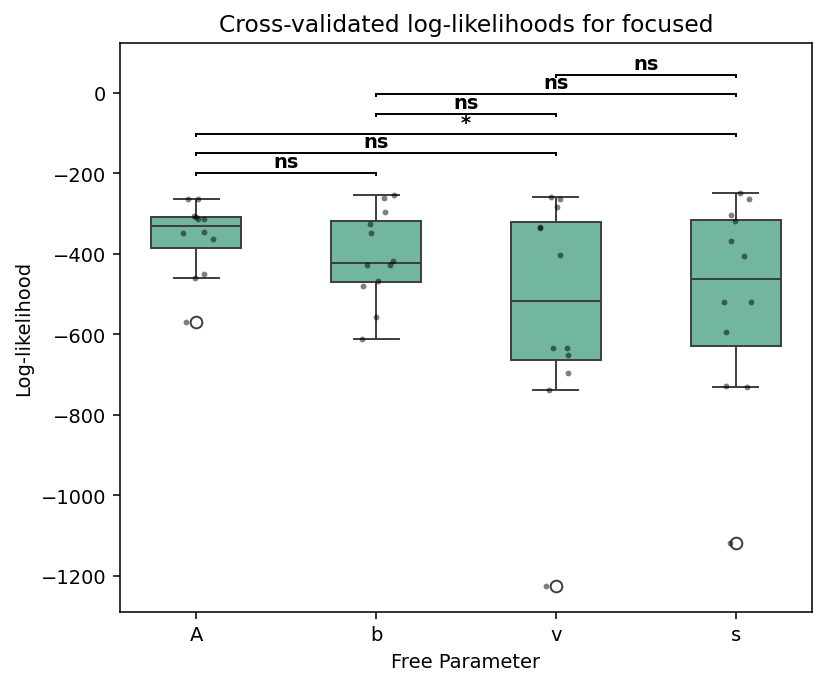

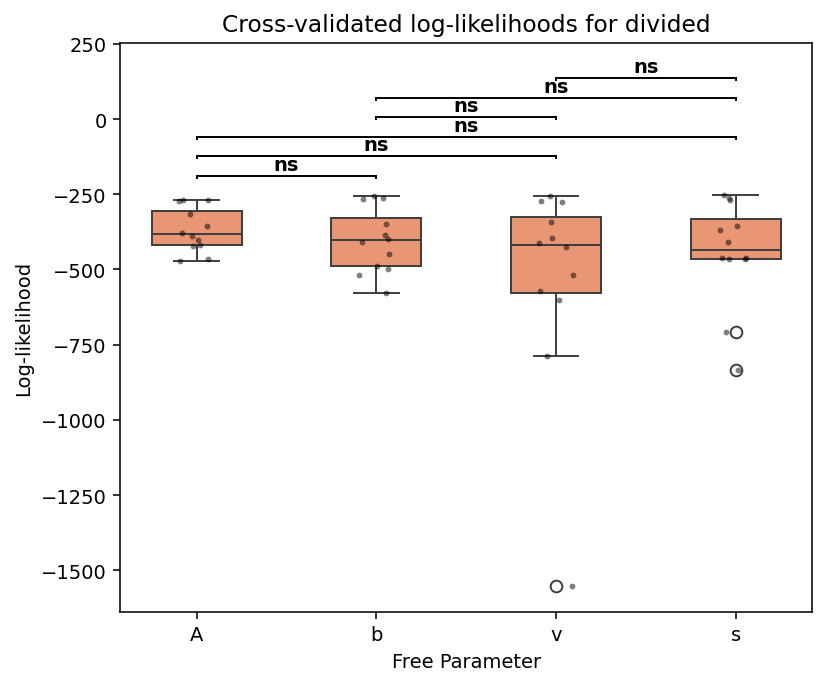

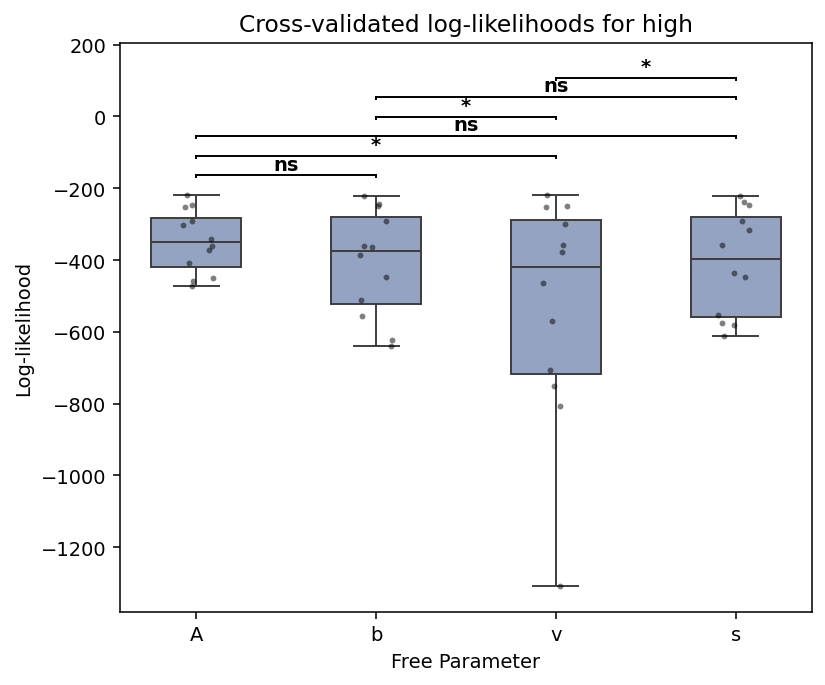

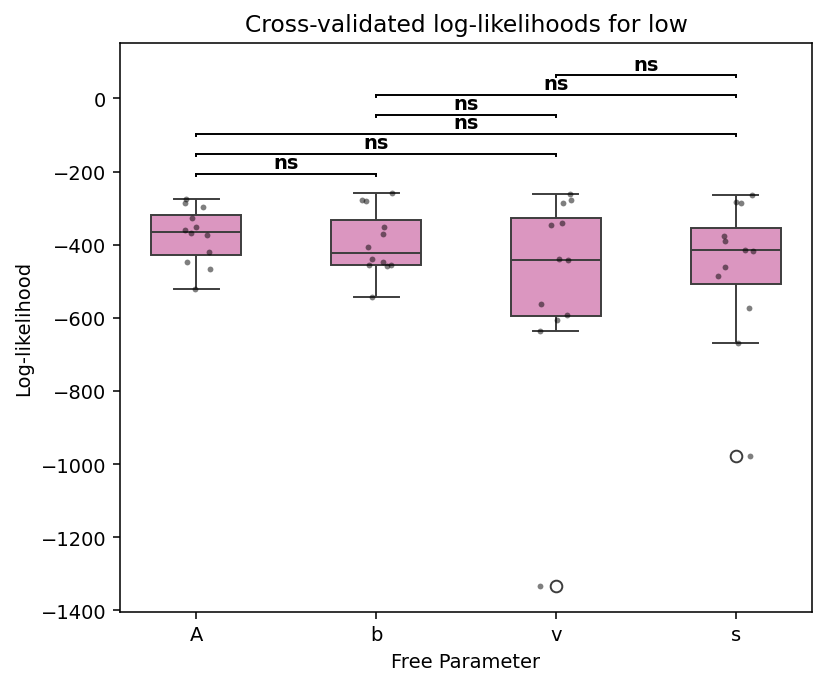

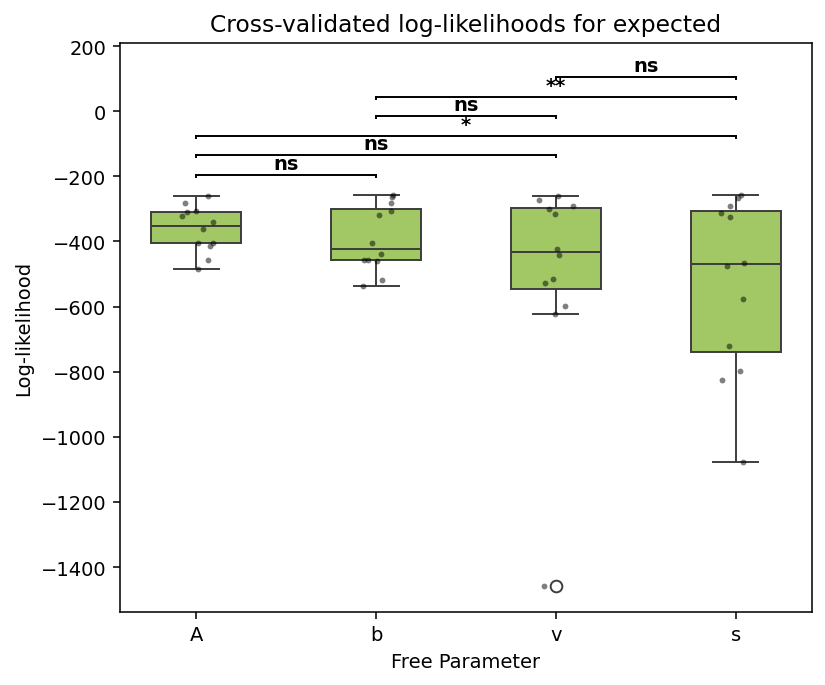

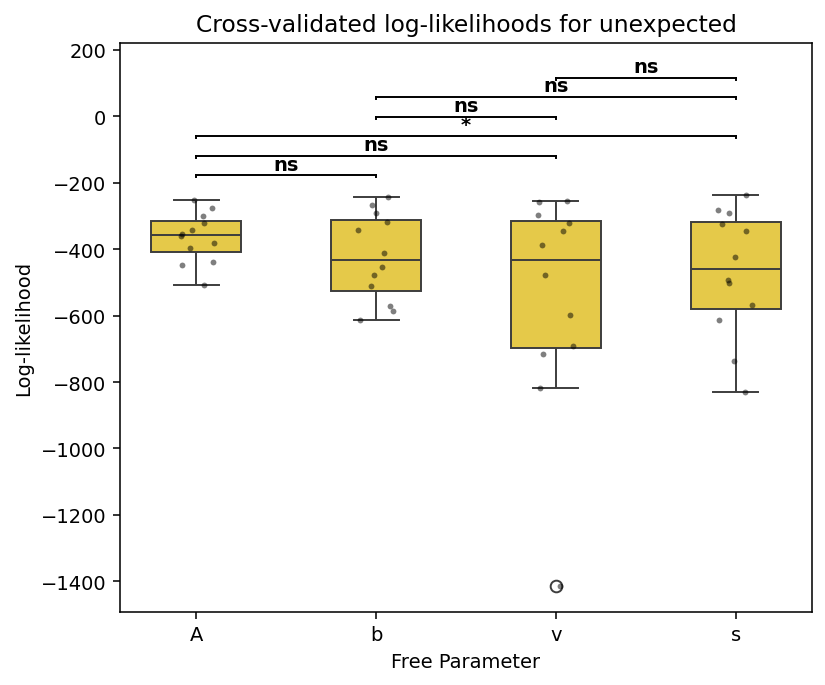

In [31]:
# Loop through cond_by_param_res 
# for each condition, plot the cross-validated log-likelihoods for each parameter
# sns box plot with jittered data scattered on it. there should be 4 boxes (one for each param) and 12 dots in each box for each subject
# Add Mann-Whitney U tests between all pairs of parameters

from scipy.stats import mannwhitneyu, wilcoxon
from itertools import combinations

def get_significance_stars(p_value):
    """Convert p-value to significance stars"""
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

def add_significance_bars(ax, data, param_names):
    """Add significance bars and stars above boxplot"""
    # Get the maximum y-value for positioning bars
    max_y = max([max(data[param]) for param in param_names])
    y_range = max_y - min([min(data[param]) for param in param_names])
    
    # Calculate all pairwise comparisons
    comparisons = list(combinations(range(len(param_names)), 2))
    
    # Height increment for stacking multiple comparison bars
    bar_height = y_range * 0.05
    
    for i, (param1_idx, param2_idx) in enumerate(comparisons):
        param1_name = param_names[param1_idx]
        param2_name = param_names[param2_idx]

        # Perform Wilcoxon signed-rank test
        statistic, p_value = wilcoxon(
            data[param1_name], 
            data[param2_name], 
            alternative='two-sided'
        )
        
        # Get significance stars
        stars = get_significance_stars(p_value)
        
        # Only show significant results to avoid clutter
        if stars:
            # Calculate bar position
            bar_y = max_y + bar_height * (i + 1)
            
            # Draw horizontal line
            ax.plot([param1_idx, param2_idx], [bar_y, bar_y], 
                   color='black', linewidth=1)
            
            # Draw vertical ticks
            ax.plot([param1_idx, param1_idx], [bar_y - bar_height*0.1, bar_y], 
                   color='black', linewidth=1)
            ax.plot([param2_idx, param2_idx], [bar_y - bar_height*0.1, bar_y], 
                   color='black', linewidth=1)
            
            # Add significance stars
            ax.text((param1_idx + param2_idx) / 2, bar_y + bar_height*0.1, 
                   stars, ha='center', va='bottom', fontsize=10, fontweight='bold')

# Get Set2 colors for each condition
set2_colors = sns.color_palette("Set2", n_colors=len(cond_by_param_res))

for plot_idx, (cond_name, param_ll) in enumerate(cond_by_param_res):
    plt.figure(figsize=(6, 5))
    
    # Use the same color for all boxes in this plot
    plot_color = set2_colors[plot_idx]
    
    # Create the boxplot with single color
    box_plot = sns.boxplot(data=pd.DataFrame(param_ll), color=plot_color, width=0.5)
    sns.stripplot(data=pd.DataFrame(param_ll), color='black', alpha=0.5, jitter=True, size=3)
    
    # Add significance bars
    param_names = list(param_ll.keys())
    add_significance_bars(plt.gca(), param_ll, param_names)
    
    plt.title(f"Cross-validated log-likelihoods for {cond_name}")
    plt.xlabel("Free Parameter")
    plt.ylabel("Log-likelihood")
    plt.xticks(rotation=0)
    
    # Adjust y-axis to accommodate significance bars
    ax = plt.gca()
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1] * 1.15)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistical summary
    # print(f"\nStatistical comparisons for {cond_name}:")
    # param_names = list(param_ll.keys())
    # for param1, param2 in combinations(param_names, 2):
    #     statistic, p_value = wilcoxon(
    #         param_ll[param1], 
    #         param_ll[param2], 
    #         alternative='two-sided'
    #     )
    #     stars = get_significance_stars(p_value)
    #     print(f"  {param1} vs {param2}: W={statistic:.1f}, p={p_value:.4f} {stars}")
    # print("-" * 50)

In [ ]:
comparisons = [
    ("low", "high", "Coherence"),
    ("divided", "focused", "Attention"),
    ("unexpected", "expected", "Expectation")
]

colors = [("#c8c8c8", "#4b4b4b"), ("#b2d1dc", "#006488"), ("#cc6980", "#b62748")]

for (cond1, cond2, title), (color1, color2) in zip(comparisons, colors):
    df1 = summs[cond1]
    df2 = summs[cond2]

    # Extract means and HDIs
    means1 = df1['mean'].to_numpy()
    means2 = df2['mean'].to_numpy()
    lower1 = means1 - df1['hdi_3%'].to_numpy()
    upper1 = df1['hdi_97%'].to_numpy() - means1
    lower2 = means2 - df2['hdi_3%'].to_numpy()
    upper2 = df2['hdi_97%'].to_numpy() - means2

    # X positions
    x = range(len(means1))
    width = 0.35

    fig, ax = plt.subplots()
    ax.bar([xi - width/2 for xi in x], means1, width, label=cond1, 
           yerr=[lower1, upper1], capsize=5, color=color1)
    ax.bar([xi + width/2 for xi in x], means2, width, label=cond2, 
           yerr=[lower2, upper2], capsize=5, color=color2)

    ax.set_xticks(x)
    ax.set_xticklabels([f"v_{col_to_angle[i]}" for i in x])
    ax.set_title(f"{title}: {cond1.capitalize()} vs {cond2.capitalize()}")
    ax.set_ylabel("Drift rate (v)")
    ax.legend( loc='upper right', frameon=False)
    plt.show()
